In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import(
    Conv2D,
    MaxPooling2D,
    Dense,
    Flatten,
    Dropout
)
from tensorflow.keras.preprocessing.image import(
    ImageDataGenerator
)
import matplotlib.pyplot as plt

In [5]:
train_datagen=ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)
validation_datagen=ImageDataGenerator(
    rescale=1./255
)

In [9]:
train_dataset=train_datagen.flow_from_directory(
    'dataset/train',
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

validation_dataset=validation_datagen.flow_from_directory(
    'dataset/validate',
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

Found 8 images belonging to 3 classes.
Found 8 images belonging to 3 classes.


In [12]:
model=Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(150,150,3)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(1,activation='sigmoid')
])

model.summary()

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history=model.fit(
    train_dataset,
    epochs=10,
    validation_data=validation_dataset
)

model.save('saved_model.h5')
print('Model saved successfully')

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 700ms/step - accuracy: 0.5000 - loss: 0.5887 - val_accuracy: 0.5000 - val_loss: -5.4640
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.5000 - loss: -5.7855 - val_accuracy: 0.5000 - val_loss: -16.7972
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.5000 - loss: -17.4210 - val_accuracy: 0.5000 - val_loss: -38.5123
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.5000 - loss: -38.1180 - val_accuracy: 0.5000 - val_loss: -76.7711
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.5000 - loss: -73.8891 - val_accuracy: 0.5000 - val_loss: -138.6972
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.5000 - loss: -130.8575 - val_accuracy: 0.5000 - val_loss: -233.6876
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.5000 - loss: -221.1506 - val_accuracy: 0.5000 - val_loss: -373.6771
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.5000 - loss: -315.0525 - 

Model saved successfully


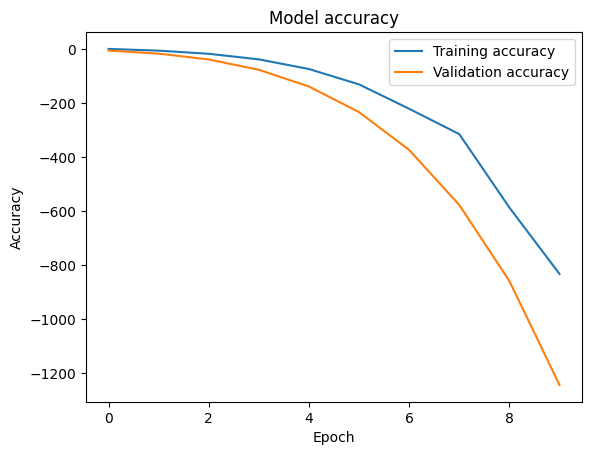

In [13]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Training accuracy','Validation accuracy'])
plt.show()

In [21]:
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

model=load_model('saved_model.h5')
img=image.load_img(
        'dataset/train/dogs/dog1.png',
        target_size=(150,150)
)
img_array=image.img_to_array(img)

img_array=np.expand_dims(img_array,axis=0)

img_array=img_array/255.0

prediction=model.predict(img_array)

if prediction[0][0]>0.5:
    print("Dog")
    print("Confidence : ",prediction[0][0]*100)

else:
    print("Cat")
    print("Confidence : ",(1-prediction[0][0]*100))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Dog
Confidence :  100.0
